# HR Analytics: Job Change of Data Scientists

This analysis focuses on understanding the factors that lead data scientists to look for a job change. The dataset is sourced from Kaggle: "HR Analytics: Job Change of Data Scientists".

In [2]:
# Install required libraries
!pip install kagglehub pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import shutil
import os

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

/home/iamtrazy/stuff/BIS/ASS1/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Download latest version of the dataset
path = kagglehub.dataset_download("arashnic/hr-analytics-job-change-of-data-scientists")

print("Path to dataset files:", path)

# Locate the csv file in the downloaded path
csv_file = os.path.join(path, "aug_train.csv")

# Copy it to current directory for convenience
if os.path.exists(csv_file):
    shutil.copy(csv_file, "aug_train.csv")
    print("Copied aug_train.csv to current directory")
else:
    print("aug_train.csv not found in download path")

Path to dataset files: /home/iamtrazy/.cache/kagglehub/datasets/arashnic/hr-analytics-job-change-of-data-scientists/versions/1
Copied aug_train.csv to current directory


In [5]:
# Load the dataset
df = pd.read_csv("aug_train.csv")

# Display first few rows
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


In [6]:
# Basic Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  str    
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  str    
 4   relevent_experience     19158 non-null  str    
 5   enrolled_university     18772 non-null  str    
 6   education_level         18698 non-null  str    
 7   major_discipline        16345 non-null  str    
 8   experience              19093 non-null  str    
 9   company_size            13220 non-null  str    
 10  company_type            13018 non-null  str    
 11  last_new_job            18735 non-null  str    
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), str(10)
memory usage: 2.

In [7]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

In [8]:
# Drop rows with missing values for this analysis
df_clean = df.dropna()
print(f"Original shape: {df.shape}, Cleaned shape: {df_clean.shape}")

Original shape: (19158, 14), Cleaned shape: (8955, 14)


## 2. Exploratory Data Analysis (EDA)

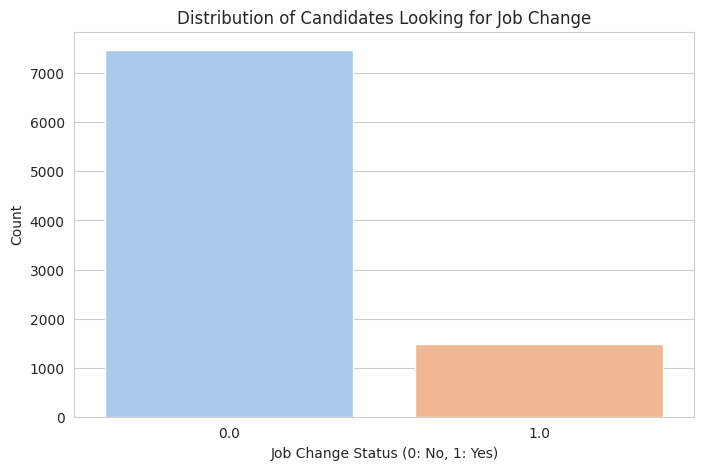

In [9]:
# Target Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="target", data=df_clean, hue="target", legend=False, palette="pastel")
plt.title("Distribution of Candidates Looking for Job Change")
plt.xlabel("Job Change Status (0: No, 1: Yes)")
plt.ylabel("Count")
plt.savefig("images/ss1.png")
plt.show()

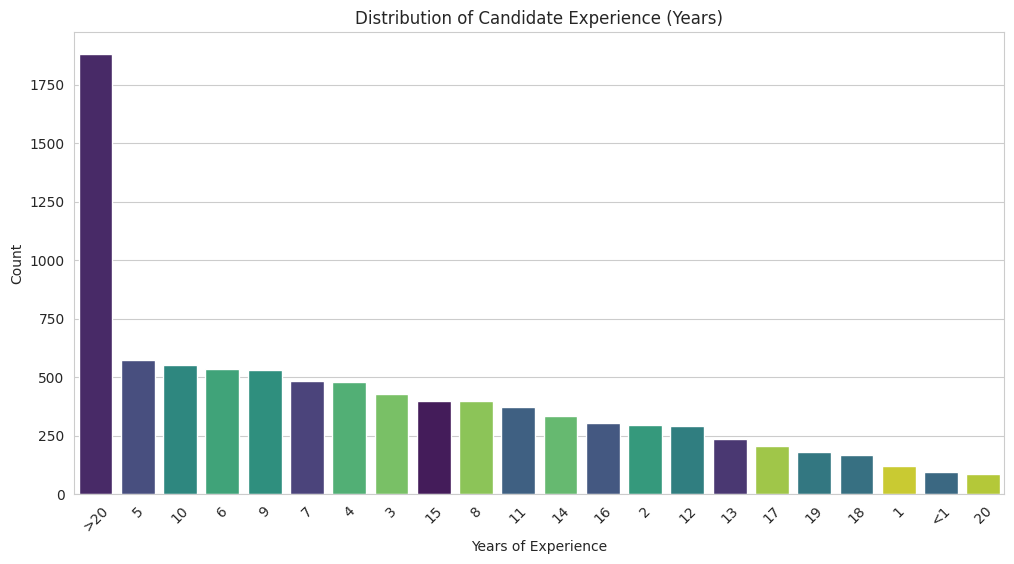

In [10]:
# Experience Distribution
plt.figure(figsize=(12, 6))
order = df_clean["experience"].value_counts().index
sns.countplot(x="experience", data=df_clean, order=order, hue="experience", legend=False, palette="viridis")
plt.title("Distribution of Candidate Experience (Years)")
plt.xlabel("Years of Experience")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.savefig("images/ss2.png")
plt.show()

## 3. Factors Influencing Job Change

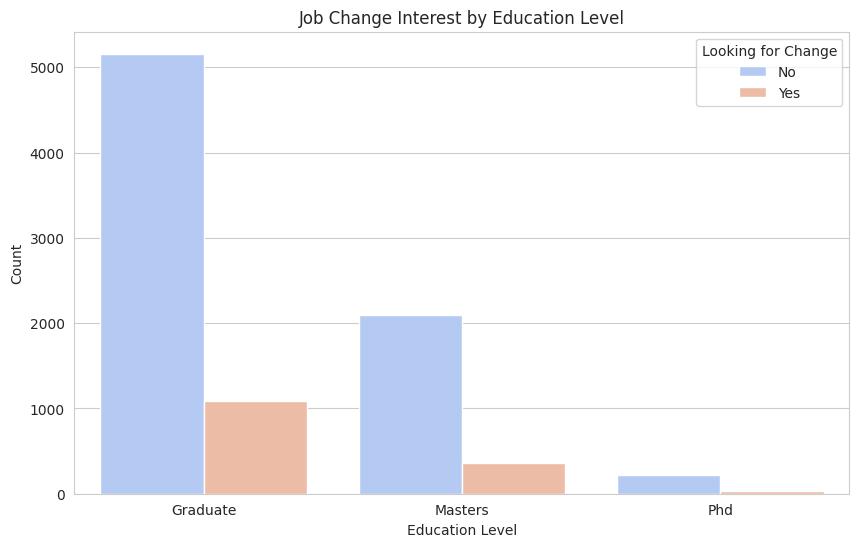

In [11]:
# Job Change by Education Level
plt.figure(figsize=(10, 6))
sns.countplot(x="education_level", hue="target", data=df_clean, palette="coolwarm")
plt.title("Job Change Interest by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.legend(title="Looking for Change", labels=["No", "Yes"])
plt.savefig("images/ss3.png")
plt.show()

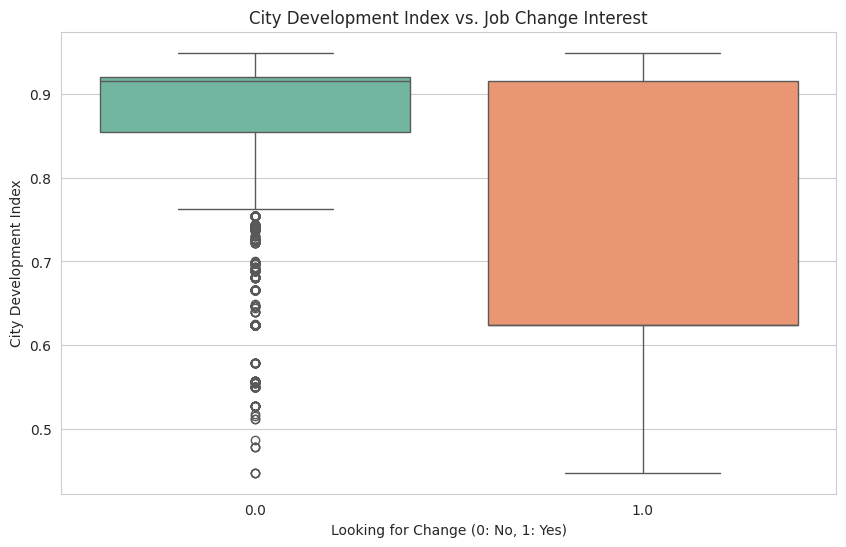

In [12]:
# City Development Index vs. Job Change
plt.figure(figsize=(10, 6))
sns.boxplot(x="target", y="city_development_index", data=df_clean, hue="target", legend=False, palette="Set2")
plt.title("City Development Index vs. Job Change Interest")
plt.xlabel("Looking for Change (0: No, 1: Yes)")
plt.ylabel("City Development Index")
plt.savefig("images/ss4.png")
plt.show()

## 4. Correlation Analysis

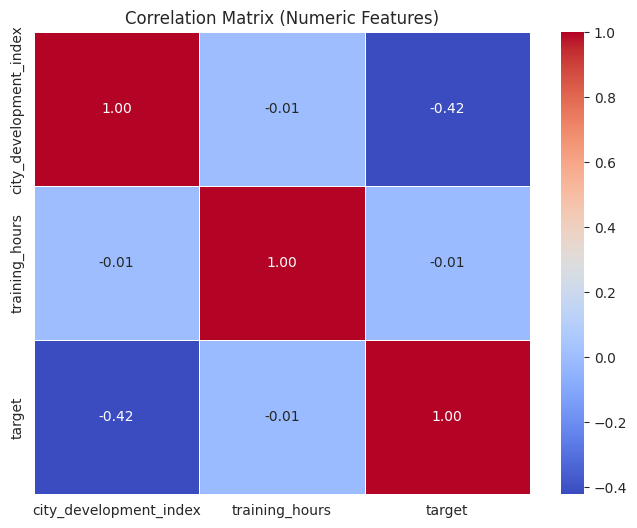

In [13]:
# Correlation Matrix
numeric_cols = ["city_development_index", "training_hours", "target"]
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix (Numeric Features)")
plt.savefig("images/ss5.png")
plt.show()